# **Notebook 9 – Outlier Detection**

## **1. What are Outliers?**



**Understand the Concept**

* Outliers are values that are very different from the other values in a dataset.
* They can be unusually high or unusually low.
* Outliers may happen because of errors, unusual events, or real situations.



**Demonstrate the Concept**

**Real-Life Example:**

* A shop usually sells 20 to 50 products per day.
* One day, it sells 500 products because of a special sale.
* The value 500 can be an outlier.

**AI/ML Example:**

* Outliers can affect the results of Machine Learning models.
* We usually check and handle unusual values before training a model.


In [2]:
# Labraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Implement the Concept:
# Sales data
sales = pd.DataFrame([ 35,28, 38, 40, 42, 48, 500]) # 500 - special sales
print("Sales Data:", sales)
print("Possible Outlier:", 500)

Sales Data:      0
0   35
1   28
2   38
3   40
4   42
5   48
6  500
Possible Outlier: 500


## **2. Types of Outliers**

**Understand the Concept**

* A point can be far from the other values, far from a group, or unusual because of a pattern.
* Common types are point outliers, contextual outliers, and collective outliers.
    * Point Outlier - One unusual value
    * Contextual Outlier - Unusual for a situation
    * Collective Outlier - Group of unusual values


**Demonstrate the Concept**

**Real-Life Example:**

* A person normally spends ₹500 to ₹2,000 per month.
* One month, the person spends ₹50,000 because of a health problem.
* This can be a point outlier.



In [4]:
# Implement the Concept:
# Monthly spending data
spending = np.array([500, 800, 1000, 1200, 1500, 50000])

# Mean
mean_spending = np.mean(spending)

print("Spending Data:", spending)
print("Mean Spending:", mean_spending)
print("Possible Point Outlier:", 50000)

Spending Data: [  500   800  1000  1200  1500 50000]
Mean Spending: 9166.666666666666
Possible Point Outlier: 50000


## **3. Detecting Outliers**



**Understand the Concept**

* Detecting outliers means finding values that are very different from the other values.
* We can use different methods to find them, common methods are IQR, Z-Score, box plot & scatter plot.



**Demonstrate the Concept**

**Real-Life Example:**

* A shop usually gets 100 to 200 orders per day.
* One day, it gets 2,000 orders.
* The shop can use outlier detection methods to check whether 2,000 is an unusual value.

**AI/ML Example:**

* Outlier detection is used during data cleaning.
* It helps find unusual values before training a Machine Learning model.
* IQR and Z-Score are two common methods.


In [5]:
# Implement the Concept:
# Daily order data
orders = pd.DataFrame([100, 120, 110, 130, 150, 2000])
print("Data Description \n", orders.describe())


Data Description 
                  0
count     6.000000
mean    435.000000
std     766.883303
min     100.000000
25%     112.500000
50%     125.000000
75%     145.000000
max    2000.000000


## **4. IQR Method**

**Understand the Concept**

* IQR method is used to find outliers in a dataset.
* IQR means Interquartile Range.
* It uses Q1 and Q3 to find the middle 50% of the data.
* Values below lower bound or above upper bound are treated as outliers.

**Formula**

* IQR = Q3 - Q1
* Lower bound = Q1 - 1.5 × IQR
* Upper bound = Q3 + 1.5 × IQR



**Demonstrate the Concept**

**Real-Life Example:**

* A shop usually receives between 10 and 20 orders per day.
* One day it receives 50 orders.
* The IQR method can help check whether 50 is an unusual value.


In [6]:
# Implement the Concept:
# Daily orders
orders = np.array([10, 12, 13, 15, 16, 18, 50])

# Q1 & Q3
q1 = np.percentile(orders, 25)
q3 = np.percentile(orders, 75)

# IQR
iqr = q3 - q1

# limits
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# Outliers
outliers = orders[(orders < lower_limit) | (orders > upper_limit)] # Fliter a data

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Outliers:", outliers)

Q1: 12.5
Q3: 17.0
IQR: 4.5
Lower Limit: 5.75
Upper Limit: 23.75
Outliers: [50]


## **5. Z-Score Method**



**Understand the Concept**

* Z-Score shows how far a value is from the mean.
* It is measured using standard deviation.
* Z-Score close to 0 means the value is close to the mean.
* Z-Score above +3 or below -3 is commonly treated as an outlier.

**Formula :** Z-Score = (X - Mean) / Standard Deviation



**Demonstrate the Concept**

**Real-Life Example:**

* A company checks the delivery time of its orders.
* Most orders take around 10 to 15 minutes.
* If one order takes 350 minutes, Z-Score can help check whether it is an unusual value.



In [23]:
# Implement the Concept:
# Delivery time data
delivery_time = np.array([10,12,15,11,13,350])

# mean and standard deviation
mean = np.mean(delivery_time)
std = np.std(delivery_time)

# Z-Scores
z_scores = (delivery_time - mean) / std

# outliers using ±3 threshold
outliers = delivery_time[np.abs(z_scores) > 3]
print("Mean:", mean)
print("Standard Deviation:", std)
print("Z-Scores:", z_scores)
print("Outliers:", outliers)

Mean: 68.5
Standard Deviation: 125.90042361591428
Z-Scores: [-0.46465292 -0.44876735 -0.424939   -0.45671014 -0.44082457  2.23589399]
Outliers: []


## **6. Box Plot**



**Understand the Concept**

* A box plot is a graph used to show how data is spread.
* It shows the minimum, Q1, median, Q3, and maximum values.
* It can also help us find outliers.
* Outliers are usually shown as separate points outside the box.



**Demonstrate the Concept**

**Real-Life Example:**

* A company checks the salary of its employees.
* A box plot can show the middle salary range and very high or low salaries.



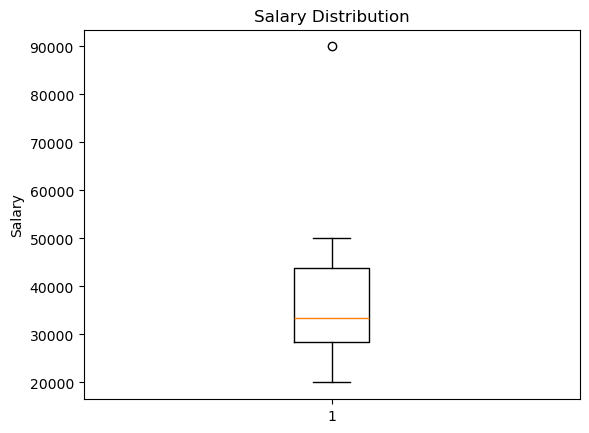

In [25]:
# Implement the Concept:
# Employee salaries
salaries = [20000, 25000, 28000, 30000, 32000, 35000, 40000, 45000, 50000, 90000]

# Box plot
plt.boxplot(salaries)
plt.ylabel("Salary")
plt.title("Salary Distribution")
plt.show()

**Explaination:**

* Most employee salaries are between ₹20,000 and ₹50,000.
* ₹90,000 is much higher than the other salaries.

## **7. Scatter Plot**



**Understand the Concept**

* A scatter plot is a graph used to show the relationship between two numerical variables.
* Each point represents one observation.
* It helps us see patterns, relationships, and possible outliers.



**Demonstrate the Concept**

**Example:**

* Study Hours: 2, 4, 6, 8, 9, 10
* Exam Marks: 50, 60, 70, 80, 55, 90
* The point at 9 hours and 55 marks is far from the general pattern.
* This can be an unusual observation.

**AI/ML Example:**

* Scatter plots are useful during Exploratory Data Analysis.
* They help us understand relationships between features and identify unusual data points.


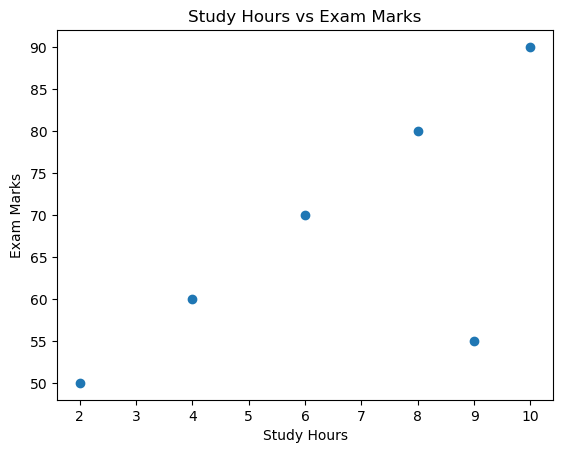

In [27]:
# Implement the Concept:
# Hours & marks
study_hours = [2, 4, 6, 8, 9, 10]
exam_marks = [50, 60, 70, 80, 55, 90]

# Scatter plot
plt.scatter(study_hours, exam_marks)
plt.xlabel("Study Hours")
plt.ylabel("Exam Marks")
plt.title("Study Hours vs Exam Marks")
plt.show()

**Explaination:**

* Most points show that marks increase with study hours.
* The 9-hour and 55-mark point does not follow the general pattern.
* A scatter plot helps us identify such unusual points.